# Intro to Scikit-Learn (sklearn)

Demo some of the most useful functions of the beautiful Scikit-Learn library

Topics

0. An end-to-end Scikit-Learn workflow
1. Getting the data ready
2. Choosing the right estimator/algorithm for our problems
3. Fit the model/algorithm and use it to make predictions on our data
4. Evaluating the model
5. Improve the model
6. Save and Load a trained model
7. Putting it all together

## 0. An End-to-End Scikit-Learn (SKLearn) workflow

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [130]:
topics_learnt =['0. An end-to-end Scikit-Learn workflow','1. Getting the data ready','2. Choose the right estimator/algo for our problems','3. Fit the model/algo for problems and use it to make predictions on our data',
                '4. Evaluating a mdoel','5. Improve a model','6. Save and load a trained model','7. Putting it all together']
topics_learnt

['0. An end-to-end Scikit-Learn workflow',
 '1. Getting the data ready',
 '2. Choose the right estimator/algo for our problems',
 '3. Fit the model/algo for problems and use it to make predictions on our data',
 '4. Evaluating a mdoel',
 '5. Improve a model',
 '6. Save and load a trained model',
 '7. Putting it all together']

In [131]:
# 1 Get the data ready
heartDisease = pd.read_csv('heart-disease.csv')
heartDisease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [132]:
# Goal is to predict 1(Heart Disease) or 0(Doesn't have heart disease)
# Create features/data/feature variables
X = heartDisease.drop("target", axis=1)

# Created labels
Y = heartDisease['target']

# Main modules in sklearn library

1. model_selection: Splitting data and tuning settings.
2. sklearn.ensemble: Advanced models like Random Forests and Gradient Boosting.
3. sklearn.linear_model: Simple models like Linear and Logistic Regression.
4. sklearn.preprocessing: Cleaning, scaling, and preparing your raw data.
5. sklearn.metrics: Scoring how well your model performed.

There are many but these are frequently used 

In [133]:
#One time thing to install Scikit pip install scikit-learn pandas numpy use pandas and numpy if already not installed 
# 2. Choose the right model and hyperparameters
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()

# Use the default hyperparameters
clf.get_params()


{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [134]:
#3. Fit the model to the training data
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [135]:
clf.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [136]:
# we can get rid of the abve table by using a semi colon
clf.fit(X_train, Y_train);

In [137]:
y_preds = clf.predict(X_test)
y_preds

array([1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0])

In [138]:
Y_test

78     1
33     1
140    1
130    1
72     1
      ..
203    0
274    0
247    0
42     1
245    0
Name: target, Length: 61, dtype: int64

In [139]:
#4 Evaluate the Model on the training data and test data
clf.score(X_train, Y_train)

1.0

In [140]:
clf.score(X_test, Y_test)

0.8360655737704918

In [141]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(classification_report(Y_test, y_preds))

              precision    recall  f1-score   support

           0       0.88      0.77      0.82        30
           1       0.80      0.90      0.85        31

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61



In [142]:
confusion_matrix(Y_test, y_preds)

array([[23,  7],
       [ 3, 28]])

In [143]:
accuracy_score(Y_test, y_preds)

0.8360655737704918

In [144]:
# 5. Experiment and Improve the model
np.random.seed(42)
for i in range(10,100,10):
    print(f"Trying model with estimators {i}")
    clf = RandomForestClassifier(n_estimators = i)
    clf.fit(X_train, Y_train)
    print(f"Model Accuracy on test set : {clf.score(X_test, Y_test)*100:.2f}%")
    print("")

Trying model with estimators 10
Model Accuracy on test set : 77.05%

Trying model with estimators 20
Model Accuracy on test set : 80.33%

Trying model with estimators 30
Model Accuracy on test set : 77.05%

Trying model with estimators 40
Model Accuracy on test set : 81.97%

Trying model with estimators 50
Model Accuracy on test set : 80.33%

Trying model with estimators 60
Model Accuracy on test set : 83.61%

Trying model with estimators 70
Model Accuracy on test set : 80.33%

Trying model with estimators 80
Model Accuracy on test set : 80.33%

Trying model with estimators 90
Model Accuracy on test set : 77.05%



In [145]:
# 6. Save a model and load it
import pickle

pickle.dump(clf, open("random_forset_classification_HeartDisease1.pkl", "wb"))

In [146]:
loadHeartDiseasePreicitonModel = pickle.load(open("random_forset_classification_HeartDisease1.pkl", "rb"))
loadHeartDiseasePreicitonModel.score(X_test, Y_test)

0.7704918032786885

## 1.Getting data ready to be used with ML
Three main things we have to do

    1. Split the data into features and labels (usually 'X' & 'Y')
    2. Filling (also called imputing) or disregarding missing values
    3. Converting non numerical values to numerical values also called as feature encoding

In [147]:
heartDisease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [148]:
X = heartDisease.drop("target", axis=1)

In [149]:
Y = heartDisease["target"]

In [150]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [151]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((242, 13), (61, 13), (242,), (61,))

In [152]:
X.shape

(303, 13)

# 1.1 Make sure it's all numerical

In [153]:
carSalesExtended = pd.read_csv('dataFolder/car-sales-extended.csv')
carSalesExtended.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043


In [154]:
len(carSalesExtended)

1000

In [155]:
carSalesExtended.dtypes

Make               str
Colour             str
Odometer (KM)    int64
Doors            int64
Price            int64
dtype: object

In [156]:
# split into X and Y
X = carSalesExtended.drop("Price", axis=1)
Y = carSalesExtended["Price"]

# split it into training and test
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)


In [157]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
#model.fit(X_train, Y_train) # since these are not numerical the below errors are shown so we need an encoder and will also use a categorical features to make catergorical things into numbers
#model.score(X_test, Y_test)

In [158]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour", "Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot_text", one_hot, categorical_features)], remainder="passthrough")
transformed_X = transformer.fit_transform(X)
transformed_X

new_columns  = transformer.named_transformers_["one_hot_text"].get_feature_names_out()
print(new_columns)

['Make_BMW' 'Make_Honda' 'Make_Nissan' 'Make_Toyota' 'Colour_Black'
 'Colour_Blue' 'Colour_Green' 'Colour_Red' 'Colour_White' 'Doors_3'
 'Doors_4' 'Doors_5']


In [159]:
pd.DataFrame(transformed_X)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,35431.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,192714.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,84714.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,154365.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,181577.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35820.0
996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,155144.0
997,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,66604.0
998,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,215883.0


dummies = pd.get_dummies(carSalesExtended[["Make", "Colour", "Doors"]])
print(dummies # not recommended it's just to quickly read it

In [160]:
np.random.seed(42)
X_train, X_test, Y_train, Y_test = train_test_split(transformed_X, Y, test_size=(0.2))
model.fit(X_train, Y_train);

In [161]:
model.score(X_test, Y_test)

0.3235867221569877

### 1.2 What if there were missing values

1) Fill them with some value (also known as imputation)
2) Remove the samples with missing data altogether


In [162]:
carSalesMissing = pd.read_csv('dataFolder/car-sales-extended-missing-data.csv')

In [163]:
carSalesMissing.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

#### Option 1: Fill misisng data with Pandas

In [164]:
print(len(carSalesMissing))
carSalesMissing.dropna(subset="Price", inplace=True)
carSalesMissing['Odometer (KM)'] = carSalesMissing['Odometer (KM)'].fillna(carSalesMissing['Odometer (KM)'].mean())
carSalesMissing['Make'] = carSalesMissing['Make'].fillna('missing')  # This is not required in the latest version of Scikit the encoder can handle NaN but just doing it here to follow the tutorial
carSalesMissing['Colour'] = carSalesMissing['Colour'].fillna('missing')
carSalesMissing['Doors'] = carSalesMissing['Doors'].fillna(4)
print(len(carSalesMissing))
carSalesMissing.isna().sum()

1000
950


Make             0
Colour           0
Odometer (KM)    0
Doors            0
Price            0
dtype: int64

In [165]:
X = carSalesMissing.drop('Price', axis=1)
Y = carSalesMissing['Price']
categorical_features = ['Make', 'Colour', 'Doors']
one_hot = OneHotEncoder(sparse_output=False) # not giving this would give a sparsed column in real time you don't need this to make the system more efficient
transformer = ColumnTransformer([('one_hot_missing_data_car_sales_text', one_hot, categorical_features)], remainder='passthrough', )
transformedX  = transformer.fit_transform(X)
columns =  transformer.named_transformers_['one_hot_missing_data_car_sales_text'].get_feature_names_out()
columns

array(['Make_BMW', 'Make_Honda', 'Make_Nissan', 'Make_Toyota',
       'Make_missing', 'Colour_Black', 'Colour_Blue', 'Colour_Green',
       'Colour_Red', 'Colour_White', 'Colour_missing', 'Doors_3.0',
       'Doors_4.0', 'Doors_5.0'], dtype=object)

In [166]:
pd.DataFrame(transformedX)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,35431.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,192714.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,84714.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,154365.0
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,181577.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35820.0
946,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,155144.0
947,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,66604.0
948,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,215883.0


In [167]:
#### Option 2: Fill misisng data with Scikit
carSalesMissing = pd.read_csv('dataFolder/car-sales-extended-missing-data.csv')

In [168]:
carSalesMissing.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

In [169]:
carSalesMissing.dropna(subset='Price', inplace=True) #It is always better to drop empty labels sincethey act like the answer not having an answer is not very helpful
carSalesMissing.isna().sum()

Make             47
Colour           46
Odometer (KM)    48
Doors            47
Price             0
dtype: int64

In [170]:
X = carSalesMissing.drop('Price', axis=1)
Y = carSalesMissing['Price']
np.random.seed(42)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [171]:
from sklearn.impute import SimpleImputer
categoricalImputer = SimpleImputer(strategy="constant", fill_value = 'missing') # Imputer for Categorical values
numericalImputer = SimpleImputer(strategy="mean") # Imputer for numeric values we will fill it with mean value
doorImputer = SimpleImputer(strategy="most_frequent") #Imputer will use most frequent values to fill the missing values


In [172]:
carSalesMissing.head(2)

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0


In [173]:
categoricalFeature = ['Make', 'Colour']
doorFeature = ['Doors']
numericalFeatures = ['Odometer (KM)']

In [174]:
from sklearn.compose import ColumnTransformer
imputer = ColumnTransformer([
    ('cat_featrue', categoricalImputer, categoricalFeature), 
    ('door_feature', doorImputer, doorFeature),
    ('num_feature', numericalImputer, numericalFeatures)]);
# The reason why we do Test data and Train data Seperately is because we don't want training data to to influence test data good example would be the mean value we dont want the train data values to spill into the test data
filled_X_Train_Data = imputer.fit_transform(X_train)
filled_X_Test_Data = imputer.transform(X_test)

The difference comes down to a fundamental rule of machine learning: fit calculates parameters from the data, while transform applies those calculated parameters to the data.Your code comment is exactly right. You separate training and testing data to prevent "data leakage" (like a mean value spilling over). The choice between fit_transform and transform is how scikit-learn enforces this separation.
Here is the exact breakdown of what each one does in your code snippet:fit_transform(X_train)This is a two-in-one step used only on your training data. It does two things back-to-back:
Fit: The imputer looks at X_train, calculates the filling metrics (like the mean or most frequent value), and saves them in memory.
Transform: It uses those saved metrics to fill in the missing gaps inside X_train, outputting filled_X_Train_Data.transform(X_test)This is a one-step operation used only on your test or validation data.Transform: It fills in the missing gaps inside X_test using the exact same metrics it calculated from X_train.It does not look at X_test to calculate a new mean. If there are missing numbers in your test data, it fills them with the training data's mean. This keeps your test data completely blind to its own distribution, perfectly simulating how your model will face real-world production data.

In [175]:
filled_X_Train_Data


array([['Honda', 'White', 4.0, 71934.0],
       ['Toyota', 'Red', 4.0, 162665.0],
       ['Honda', 'White', 4.0, 42844.0],
       ...,
       ['Toyota', 'White', 4.0, 196225.0],
       ['Honda', 'Blue', 4.0, 133117.0],
       ['Honda', 'missing', 4.0, 150582.0]], shape=(760, 4), dtype=object)

In [176]:
# The above data is still not in data frame so we need to create the dataframe
filled_X_Train_DataFrame = pd.DataFrame(filled_X_Train_Data, columns=["Make", "Colour", "Doors", "Odometer (KM)"])
filled_X_Test_DataFrame = pd.DataFrame(filled_X_Test_Data, columns=["Make", "Colour", "Doors", "Odometer (KM)"])

In [177]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categoricalFeatures = ["Make", "Colour", "Doors"]
oneHotEncoder = OneHotEncoder()
transformer = ColumnTransformer([('one_hot_encoder_label', oneHotEncoder, categoricalFeatures )], remainder='passthrough', sparse_threshold=0) # again keeping sparse threshold as zero so we can see the result not an efficient option
transformedTrainData = transformer.fit_transform(filled_X_Train_DataFrame)
transformedTestData = transformer.fit_transform(filled_X_Test_DataFrame)

from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(transformedTrainData, Y_train)
model.score(transformedTestData, Y_test)

0.21735623151692096

## 2.Choosing the right estimator/algorithm for your problem

1) Scikit calls model or algorithm as estimators
2) Estimators could be a classification estimator(Predicitng Heart Disease) , Regression Estimator(Predicting House Price)
3) Refer this document for help https://scikit-learn.org/stable/machine_learning_map.html
4) https://github.com/mrdbourke/zero-to-mastery-ml/blob/master/section-2-data-science-and-ml-tools/introduction-to-scikit-learn.

SGDRegressor and Lasso are two other linear regression choices sitting alongside Ridge. They solve the same task (predicting a continuous number), but they handle the underlying mathematics and data challenges differently. [1, 2] 
------------------------------
## 📉 1. Lasso Regression (Lasso)
Lasso stands for Least Absolute Shrinkage and Selection Operator. It is very similar to Ridge, but with one superpower: Feature Selection. [3, 4, 5, 6] 

* How it works: It uses "L1 Regularization." If a feature in your dataset isn't highly useful for predicting housing prices (for example, if you added a column for "average rainfall"), Lasso will shrink that feature's mathematical weight exactly to zero. [7] 
* When to use it: Use Lasso when you have a dataset with a massive number of features (dozens or hundreds of columns), and you want the model to automatically drop the useless ones to leave you with a clean, simple formula. [8, 9, 10, 11] 

## ⚡ 2. SGD Regressor (SGDRegressor)
SGD stands for Stochastic Gradient Descent. It is not a fundamentally different mathematical model; rather, it is a highly efficient way to train a linear model. [12, 13, 14] 

* How it works: Instead of looking at all 20,000+ rows of your California housing data at the exact same time to calculate the best formula (which takes a lot of computer memory), SGD looks at the data in tiny, random batches (or even one row at a time) and updates the formula step-by-step. [15, 16, 17] 
* When to use it: Use SGD when your dataset is absolutely massive (e.g., millions of rows) and your computer's RAM cannot handle loading all the data at once. It trades absolute mathematical precision for incredible speed and memory efficiency. [18, 19] 

------------------------------
## 🗺️ Where They Sit on Your Map
Think of your linear regression tools as a toolkit for different sizes and shapes of data:

| Model [20, 21, 22, 23, 24] | Use Case on the Map | Core Superpower |
|---|---|---|
| Ridge | Standard continuous data. | Prevents overfitting by shrinking weights evenly. |
| Lasso | Data with too many columns/features. | Discards useless features by setting them to zero. |
| SGDRegressor | Data with too many rows (Huge Data). | Processes data in tiny pieces so your computer doesn't crash. |

Since your California Housing dataset has a moderate number of rows (~20,000) and very few features (only 8 columns), Ridge is typically preferred over Lasso or SGDRegressor for the linear portion of your workflow. [25, 26] 

[1] [https://sdsawtelle.github.io](https://sdsawtelle.github.io/blog/output/week2-andrew-ng-machine-learning-with-python.html)
[2] [https://medium.com](https://medium.com/@msoczi/lasso-regression-step-by-step-math-explanation-with-implementation-and-example-c37df7a7dc1f)
[3] [https://online.stat.psu.edu](https://online.stat.psu.edu/stat857/node/158/)
[4] [https://napsterinblue.github.io](https://napsterinblue.github.io/notes/machine_learning/regression/ridge_lasso/)
[5] [https://wyamaka.wordpress.com](https://wyamaka.wordpress.com/wp-content/uploads/2024/09/lasso-and-ridge-1.pdf)
[6] [https://medium.com](https://medium.com/biased-algorithms/lasso-regression-from-scratch-in-python-218799c1183d)
[7] [https://medium.com](https://medium.com/data-science/machine-learning-regularization-techniques-in-real-life-your-dogs-nap-time-as-a-regularized-9c533510fe83)
[8] [https://medium.com](https://medium.com/data-science/lasso-and-ridge-regression-an-intuitive-comparison-3ee415487d18)
[9] [https://medium.com](https://medium.com/@jahanzebahmed.mail/from-equations-to-execution-the-complete-guide-to-regularization-in-linear-regression-using-numpy-ce50f7f70be7)
[10] [https://lab.learnbin.net](https://lab.learnbin.net/tools/ridge-and-lasso-regression-calculator-regularized-mlr/)
[11] [https://mr-amit.medium.com](https://mr-amit.medium.com/lasso-regression-in-r-1a1f8a4dbe8c)
[12] [https://francisbach.com](https://francisbach.com/rethinking-sgd-noise/)
[13] [https://scikit-learn.org](https://scikit-learn.org/0.20/modules/sgd.html)
[14] [https://medium.com](https://medium.com/data-science/sgdregressor-with-scikit-learn-untaught-lessons-you-need-to-know-cf2430439689)
[15] [https://www.codecademy.com](https://www.codecademy.com/resources/docs/ai/neural-networks/stochastic-gradient-descent)
[16] [https://medium.com](https://medium.com/@aniqramzan5758/gradient-descent-from-scratch-29eb9866be79)
[17] [https://www.alooba.com](https://www.alooba.com/skills/concepts/machine-learning/sgd/)
[18] [https://rpubs.com](https://rpubs.com/jt_rpubs/279269)
[19] [https://foursquare.com](https://foursquare.com/resources/blog/data/solving-the-hard-problems-in-geospatial-analytics/)
[20] [https://blog.gopenai.com](https://blog.gopenai.com/machine-learning-episode-10-regularization-techniques-ridge-and-lasso-regression-abfc88d6d320)
[21] [https://dataaspirant.com](https://dataaspirant.com/ridge-regression/)
[22] [https://www.reddit.com](https://www.reddit.com/r/mathematics/comments/da92mc/svd_in_ill_posed_problems/)
[23] [https://machinelearningcompass.com](https://machinelearningcompass.com/machine_learning_models/lasso_regression/)
[24] [https://www.instagram.com](https://www.instagram.com/reel/DZyREQEMpeq/)
[25] [https://medium.com](https://medium.com/@eduardo_90451/location-location-data-an-analysis-of-california-housing-9d7d67922e9c)
[26] [https://python.plainenglish.io](https://python.plainenglish.io/case-study-applying-scikit-learn-for-an-end-to-end-machine-learning-project-on-california-housing-d505c698987a)



In [178]:
from sklearn.datasets import fetch_california_housing
californiaHousing = fetch_california_housing()
californiaHousing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [179]:
caliHousingDf = pd.DataFrame(californiaHousing['data'], columns=californiaHousing['feature_names'])

In [180]:
caliHousingDf['target'] = californiaHousing['target']
caliHousingDf.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [181]:
from sklearn.linear_model import Ridge
X = caliHousingDf.drop('target', axis=1)
Y = caliHousingDf['target']

model = Ridge()
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
model.fit(X_train, Y_train)
model.score(X_test, Y_test)

            # --- NEW CODE TO PRINT COEFFICIENTS ---
# Create a clean DataFrame matching feature names with their coefficients
coefficients_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

# Sort them from highest impact to lowest impact
coefficients_df = coefficients_df.sort_values(by='Coefficient', ascending=False)
print(coefficients_df)

      Feature  Coefficient
3   AveBedrms     0.617318
0      MedInc     0.432476
1    HouseAge     0.009492
4  Population    -0.000002
5    AveOccup    -0.003402
2    AveRooms    -0.101255
6    Latitude    -0.421844
7   Longitude    -0.435484


In [182]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train, Y_train)
print(model.score(X_train, Y_train))
model.score(X_test, Y_test) ## looks like there is a slight Overfitting

0.9733958300014499


0.8100901365209945

## 2.2 Choosing an estimator for a classification problem

In [183]:
np.random.seed(42)
X = heartDisease.drop('target', axis=1)
Y = heartDisease['target']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.2)

In [184]:
from sklearn.svm import LinearSVC
clf = LinearSVC()
clf.fit(X_train, Y_train)
clf.score(X_train, Y_train)
clf.score(X_test, Y_test)

0.7695473251028807

In [185]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()
clf.fit(X_train, Y_train)
clf.score(X_test, Y_test)


0.8271604938271605

### Thoughts to remember
1) If you have Structured data use ensemble or linear
2) If you have Unstructured data use deep learning or transfer learning

## 3. Fit the model/algo on our data and use it to make predictions

### 3.1 Fitting a model to a data

In [186]:
heartDisease.head(1)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1


In [187]:
# choosing a model
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import train_test_split
clf = RandomForestClassifier()
np.random.seed()

X = heartDisease.drop('target', axis=1)
Y = heartDisease['target']
# Split data into train and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
clf.fit(X_train, Y_train) # Fit the model
clf.score(X_test, Y_test)# Evaluate

0.819672131147541

## 3.2 Make predictions using a machine learning model

2 ways to make predictions:

    1. predict()
    2. predict_proba()

In [188]:
# Use a tranined model to make predictions
clf.predict(X_test)
 

array([0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1])

In [189]:
np.array(Y_test) # you could just print Y_test i did this so I can visualize it 

array([0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1])

In [190]:
clf.score(X_test, Y_test)

0.819672131147541

In [191]:
y_preds = clf.predict(X_test)
np.mean(y_preds == Y_test)

np.float64(0.819672131147541)

In [192]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test, y_preds)

0.819672131147541

In [193]:
# make predicitions with predict_proba()
# Predict Proba tells the probability gives us the certainity with which it predicted the answer
# In line one it is 73% percent certain it got the right answer if say something has 51% certainity then we are not confident with the answer
clf.predict_proba(X_test[:5]) # Picking just 5 so it is easy to visualize


array([[0.55, 0.45],
       [0.74, 0.26],
       [0.4 , 0.6 ],
       [0.8 , 0.2 ],
       [0.89, 0.11]])

In [194]:
clf.predict(X_test[:5])

array([0, 0, 1, 0, 0])

In [195]:
caliHousingDf.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [196]:
from sklearn.ensemble import RandomForestRegressor
np.random.seed(42)
model = RandomForestRegressor()
X= caliHousingDf.drop('target', axis=1)
Y=caliHousingDf['target']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
model.fit(X_train, Y_train)
Y_preds = model.predict(X_test)


In [197]:
Y_preds[:5]

array([0.49275  , 0.76518  , 4.9235967, 2.55681  , 2.29356  ])

In [198]:
np.array(Y_test[:5])

array([0.477  , 0.458  , 5.00001, 2.186  , 2.78   ])

In [199]:
model.score(X_test, Y_test)

0.8058143916897114

In [200]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(Y_test, Y_preds)

0.3272560535852715

## 4. Evaluating a machine learning model
Three ways to evaluate Scikit Learn model

    1) Estimator's built in 'score()' method
    2) The 'Scoring' pearameter
    3) Problem specific metric functions
    

In [201]:
from sklearn.ensemble import RandomForestClassifier
np.random.seed(42)
clf = RandomForestClassifier()
X = heartDisease.drop('target', axis=1)
Y = heartDisease['target']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.2)
clf.fit(X_train, Y_train)
clf.score(X_test, Y_test)

0.831275720164609

In [202]:
from sklearn.ensemble import RandomForestRegressor
np.random.seed(42)
model = RandomForestRegressor()
X = caliHousingDf.drop('target', axis=1)
Y = caliHousingDf['target']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
model.fit(X_train, Y_train)
model.score(X_test, Y_test)


0.8058143916897114

## 4.2 Evaluating model using the scoring parameter

https://gartner.udemy.com/course/complete-machine-learning-and-data-science-zero-to-mastery/learn/lecture/17690056#overview

In [203]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
X = heartDisease.drop('target', axis=1)
Y = heartDisease['target']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
clf.fit(X_train, Y_train)
clf_single_score = clf.score(X_test, Y_test)
cross_val_scores = cross_val_score(clf, X, Y, cv=5) # we are setting cross value to 5 so it will do 5 fold


In [204]:
clf_cross_value_mean = np.mean(cross_val_scores)
clf_cross_value_mean

np.float64(0.811639344262295)

In [205]:
clf_single_score, clf_cross_value_mean

(0.8524590163934426, np.float64(0.811639344262295))

### 4.2.1 Classification model evaluation metrics
    1) Accuracy (default)
    2) Area under ROC curve
    3) Confusion matrix
    4) Classification report

* Skipping Accuracy since we already went through it
* Area under the receiver operating characteristic curve (AUC/ ROC) Sometime called as Area under curve(AUC) & "ROC Curve"

https://gartner.udemy.com/course/complete-machine-learning-and-data-science-zero-to-mastery/learn/lecture/17690056#overview

Remember : ROC curves are a comparison of a model's true positive rate(tpr) vs models false positive rate (fpr)

    1) True Positive(TP) = model predicts 1 when truth is 1
    2) False Positive(FP) = model predicts 1 when truth is 0
    3) True Negative(TN) = model predicts 0 when truth is 0
    4) False Negative(FN) = model predicts 0 when truth is 1


$$\text{FPR} = \frac{\text{False Positives (FP)}}{\text{False Positives (FP)} + \text{True Negatives (TN)}}$$ 
## What the pieces mean:


## In plain English:
$$\text{FPR} = \frac{\text{False Alarms}}{\text{Total Actual Negatives}}$$ 
It simply tells you: "Out of everyone who was actually a 'No', what percentage did my model mistakenly label as a 'Yes'?"
## Matching it to your code
When you look back at your printed fpr array, scikit-learn calculated every single decimal using that exact fraction. For your data, the denominator (FP + TN) was always 26, because you have 26 actual negative samples.

* When the model made 1 mistake, the formula did $\frac{1}{26} = \mathbf{0.03846}$
* When the model made 2 mistakes, the formula did $\frac{2}{26} = \mathbf{0.07692}$
* When the model made 3 mistakes, the formula did $\frac{3}{26} = \mathbf{0.11538}$




$$\text{TPR} = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Negatives (FN)}}$$ 
## What the pieces mean:

* True Positives (TP): The number of sick people your model correctly flagged as sick (successful catches).
* False Negatives (FN): The number of sick people your model completely missed and accidentally labeled as healthy.
* The Bottom Part (TP + FN): This equals the Total number of actual positive cases in your dataset.

## In plain English:
$$\text{TPR} = \frac{\text{Successful Catches}}{\text{Total Actual Positives}}$$ 
It simply tells you: "Out of everyone who was actually a 'Yes', what percentage did my model successfully catch?"
## Matching it to your code
In your printed data, the denominator (TP + FN) was always 35, because you have 35 actual positive samples. scikit-learn calculated your tpr array decimals using this exact fraction:

* When the model caught 3 positives, the formula did $\frac{3}{35} = \mathbf{0.08571}$
* When the model caught 7 positives, the formula did $\frac{7}{35} = \mathbf{0.20000}$
* When the model caught 11 positives, the formula did $\frac{11}{35} = \mathbf{0.31428}$

## The Ultimate Trade-off (TPR vs. FPR)
The entire point of the ROC graph is to balance these two formulas. When you lower your threshold, your TPR goes up (which is good, you catch more real cases), but your FPR also goes up (which is bad, you generate more false alarms). [1] 
Would you like to see how to combine these two formulas into a Confusion Matrix plot using scikit-learn to see your exact TP, FP, TN, and FN counts all at once?

Step 2: How the Graph Tracks These PairsEvery time the line on your ROC graph moves, it is recording whether your pairs are winning or losing.Remember how your graph is drawn: it sweeps through thresholds from highest score to lowest score.When the model encounters a Positive, the line moves UP.When the model encounters a Negative, the line moves RIGHT.Now, think of the graph as a literal grid of your 910 pairs. Because the line goes UP for positives and RIGHT for negatives, the line acts as a border between the pairs your model ranked correctly and the pairs it failed to rank correctly.Perfect Model (AUC = 1.0)               Your Model (AUC = 0.85)
All Positives come first!                A Negative slips ahead early!
   
   ▲                                       ▲
P  │ ┌───────────────┐                  P  │       ┌───────┐
O  │ │               │                  O  │       │       │ ◄── Area *outside*
S  │ │   ALL AREA    │                  S  │ ┌─────┘       │     the curve represents
I  │ │  UNDER THE    │                  I  │ │  85% AREA   │     the pairs the model
T  │ │  CURVE = 1.0  │                  T  │ │ UNDER THE   │     ranked wrong.
I  │ │               │                  I  │ │ CURVE       │
V  │ │               │                  V  │ │             │
E  │ └───────────────┘                  E  └─┴─────────────┘
   └─────────────────►                     └─────────────────►
        NEGATIVES                               NEGATIVES
If your model was perfect (AUC = 1.0):The model would score all 35 positives above all 26 negatives. The line would shoot straight UP to the top (skipping all negatives), and then straight RIGHT to the end (skipping all positives). It fills a perfect 1.0 square. This proves that 100% of your 910 pairs were ranked correctly.Because your model has an AUC of 0.85:Your line does not shoot straight up. Every time your model assigns a high score to a negative sample prematurely, the line is forced to take a step to the RIGHT before it finishes going UP.Every step to the right cuts out a chunk of physical space from the square. The space left outside and above the curve represents the exact number of pairs the model failed to rank correctly. The space trapped underneath represents the pairs it ranked correctly.


In [206]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
clf.fit(X_train, Y_train)
Y_Probs_= clf.predict_proba(X_test)

In [207]:
Y_probs_positive = Y_Probs_[:,1]
Y_probs_positive

array([0.08, 0.85, 0.83, 0.85, 0.86, 0.95, 0.71, 0.18, 0.56, 0.96, 0.89,
       0.18, 0.99, 0.12, 0.47, 0.98, 0.4 , 0.16, 0.3 , 0.77, 0.93, 0.65,
       0.09, 0.02, 0.98, 0.6 , 0.58, 0.09, 0.77, 0.96, 0.99, 0.01, 0.64,
       0.71, 0.85, 0.46, 0.55, 0.37, 0.99, 0.78, 0.08, 0.26, 0.16, 0.68,
       0.58, 0.9 , 0.34, 0.44, 0.46, 0.53, 0.35, 0.4 , 0.92, 0.86, 0.91,
       0.9 , 0.18, 0.66, 0.19, 0.02, 0.99])

In [208]:
# Calculate fpr, tpr,  and thresholds
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(Y_test, Y_probs_positive)
print(fpr)
print(tpr)
thresholds

[0.         0.03846154 0.03846154 0.03846154 0.03846154 0.03846154
 0.03846154 0.07692308 0.11538462 0.11538462 0.11538462 0.15384615
 0.15384615 0.19230769 0.23076923 0.26923077 0.26923077 0.30769231
 0.30769231 0.30769231 0.38461538 0.38461538 0.5        0.5
 0.53846154 0.65384615 0.73076923 0.76923077 0.80769231 0.96153846
 1.        ]
[0.         0.08571429 0.2        0.31428571 0.37142857 0.4
 0.45714286 0.51428571 0.51428571 0.54285714 0.65714286 0.65714286
 0.74285714 0.74285714 0.77142857 0.77142857 0.82857143 0.82857143
 0.88571429 0.91428571 0.91428571 0.94285714 0.94285714 0.97142857
 0.97142857 0.97142857 0.97142857 0.97142857 1.         1.
 1.        ]


array([ inf, 0.99, 0.96, 0.91, 0.9 , 0.89, 0.86, 0.85, 0.83, 0.78, 0.71,
       0.68, 0.64, 0.6 , 0.58, 0.56, 0.53, 0.47, 0.46, 0.44, 0.4 , 0.37,
       0.3 , 0.26, 0.19, 0.18, 0.16, 0.12, 0.09, 0.02, 0.01])

In [209]:
# create a function for plotting ROC curves
def plot_roc_curve(fpr, tpr):
    """
        Plots a ROC curve give in the fpr and tpr  of a model
    """

    # plot roc curve
    plt.plot(fpr, tpr, color="orange", label='ROC')
    plt.plot([0,1], color="darkblue",linestyle="--", label="Guessing")
    plt.xlabel('False Positive Rate(fpr)')
    plt.ylabel('True Positive Rate(tpr)')
    plt.title('Receiver Operating Characterictics')
    plt.legend()
    plt.show()

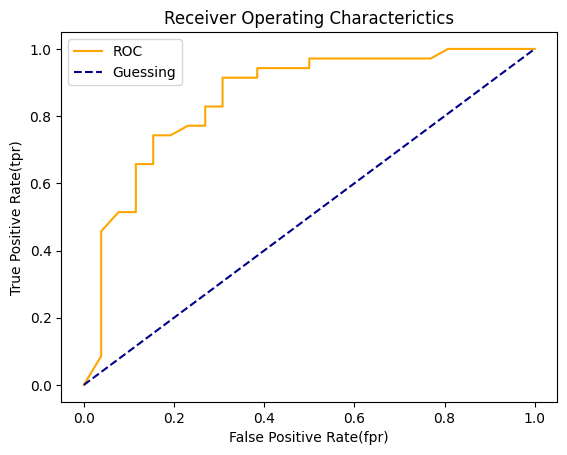

In [210]:
plot_roc_curve(fpr, tpr)

In [211]:
from sklearn.metrics import roc_auc_score
roc_auc_score(Y_test, Y_probs_positive)

0.8554945054945055

###  Confusion Matrix
A confusion matrix is a quickway to compare the labels a model predicts and the actual labels it was supposed to predict. Basically it tells us where the model is getting confused

In [212]:
from sklearn.metrics import confusion_matrix
Y_preds = clf.predict(X_test)
confusion_matrix(Y_test, Y_preds)

array([[19,  7],
       [ 6, 29]])

In [213]:
pd.crosstab(Y_test, Y_preds, rownames=["Actual Label"], colnames=["Predicted Label"])

Predicted Label,0,1
Actual Label,,
0,19,7
1,6,29


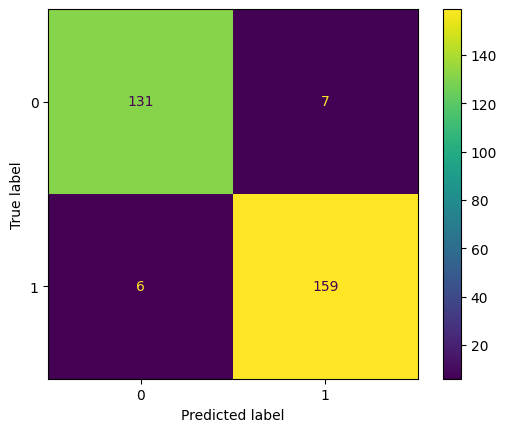

In [214]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(estimator=clf,X=X, y=Y)

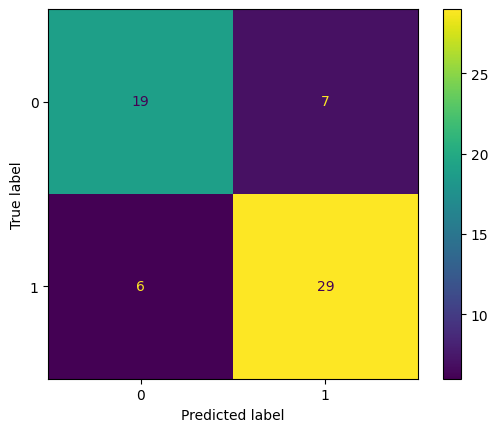

In [215]:
ConfusionMatrixDisplay.from_predictions(y_true=Y_test, y_pred=Y_preds)

### Classification Report

In [216]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, Y_preds))

              precision    recall  f1-score   support

           0       0.76      0.73      0.75        26
           1       0.81      0.83      0.82        35

    accuracy                           0.79        61
   macro avg       0.78      0.78      0.78        61
weighted avg       0.79      0.79      0.79        61



### 4.2.2 Regression model evaluation metrics
Metrics:

1) R^2 or R-Squared or coefficient of determination
2) Mean absolute error(MAE)
3) Mean squared error(MSE)

In [217]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor();
X = caliHousingDf.drop("target", axis=1)
Y = caliHousingDf["target"]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [218]:
model.score(X_test, y_test)

0.8175329391275297

In [219]:
from sklearn.metrics import r2_score
y_test_mean = np.full(len(y_test), y_test.mean())
y_test_mean

array([2.05573764, 2.05573764, 2.05573764, ..., 2.05573764, 2.05573764,
       2.05573764], shape=(4128,))

In [220]:
r2_score(y_test, y_test_mean)

0.0

In [221]:
r2_score(y_test, y_test)

1.0

**Mean absolute error(MAE)**

MAE is the avg of the absolute differnces between predictions and actual values

It gives you an idea of how wrong your models predictions are.

In [222]:
from sklearn.metrics import mean_absolute_error

y_preds = model.predict(X_test)
mae = mean_absolute_error(y_test, y_preds)
mae


0.32316899467054283

In [223]:
df = pd.DataFrame(data={
    "actual values": y_test,
    "predicted values": y_preds
})
df["differences"] = df["actual values"] - df["predicted values"]
df.head(10)

,actual values,predicted values,differences
13293,1.57200,1.494190,0.077810
6228,2.04800,2.381240,-0.333240
4072,5.00001,4.966289,0.033721
10407,2.15000,2.406190,-0.256190
3125,2.75000,1.513281,1.236719
11489,3.02700,3.698081,-0.671081
19193,1.61200,1.756360,-0.144360
1311,1.42600,1.494090,-0.068090
13617,0.83800,1.007080,-0.169080
2946,0.49800,0.536790,-0.038790


In [224]:
np.abs(df['differences']).mean()

np.float64(0.32316899467054283)

In [225]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test, y_preds)

0.24346595580858796

In [226]:
df['squared differences'] = np.square(df['differences'])
df

,actual values,predicted values,differences,squared differences
13293,1.57200,1.494190,0.077810,0.006054
6228,2.04800,2.381240,-0.333240,0.111049
4072,5.00001,4.966289,0.033721,0.001137
10407,2.15000,2.406190,-0.256190,0.065634
3125,2.75000,1.513281,1.236719,1.529474
...,...,...,...,...
5948,2.69500,2.709840,-0.014840,0.000220
5735,2.57100,2.231610,0.339390,0.115186
14582,1.75900,1.809570,-0.050570,0.002557
14602,1.59700,1.755910,-0.158910,0.025252


### 4.2.3 Finally using the 'Scoring' parameter

In [227]:
# Usually higher the score is better there are some edge cases but most of the time higher is better
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X= heartDisease.drop('target', axis=1)
y= heartDisease['target']


In [228]:
np.random.seed(42)
cv_acc = cross_val_score(clf, X, y) # default for cross value is 5 fold and the default scoring for classification problem is "accuracy"
cv_acc

array([0.81967213, 0.90163934, 0.83606557, 0.78333333, 0.78333333])

In [229]:
print(f"The Cross-Validated accuracy is: {np.mean(cv_acc)*100:.2f}%")

The Cross-Validated accuracy is: 82.48%


In [230]:
crossValue_precision = cross_val_score(clf, X, y, scoring='precision')

In [231]:
print(f"The Cross-Value precision accuracy is: {np.mean(crossValue_precision)*100:.2f}%")

The Cross-Value precision accuracy is: 80.86%


In [232]:
cv_recall = cross_val_score(clf, X, y, scoring='recall')

In [233]:
print(f"The cross value recall is: {np.mean(cv_recall)*100:.2f}%")

The cross value recall is: 84.24%


In [234]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

X = caliHousingDf.drop('target', axis=1)
y = caliHousingDf['target']

model = RandomForestRegressor();

cv_r2 = cross_val_score(model, X, y, cv=3, scoring=None) # setting 3 to make the process faster usually it is recommended to leave it at default
np.mean(cv_r2)

np.float64(0.6541215791587167)

In [235]:
# Mean Squared Error
cv_mse = cross_val_score(model, X, y, cv=3, scoring="neg_mean_squared_error") # usually lower the MSE is better but when neg is used higher is better
cv_mse

array([-0.5212377 , -0.33050031, -0.53799201])

In [236]:
#Mean Absolute Error
cv_mae = cross_val_score(model,X, y, cv=3, scoring="neg_mean_absolute_error")

In [237]:
cv_mae

array([-0.51556732, -0.42170432, -0.50787304])

In [238]:
## 4.3 Using different evaluation metrics as Scikit-Learn functions
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

np.random.seed(42)

X = heartDisease.drop('target', axis=1)
y = heartDisease['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
clf = RandomForestClassifier()

clf.fit(X_train, y_train)

y_preds = clf.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_preds)*100:.2f}%")
print(f"Precision Score : {precision_score(y_test, y_preds)*100:.2f}%")
print(f"recall : {recall_score(y_test, y_preds)*100:.2f}")
print(f"f1-Score : {f1_score(y_test, y_preds)*100:.2f}")

Accuracy : 85.25%
Precision Score : 84.85%
recall : 87.50
f1-Score : 86.15


In [239]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

np.random.seed(42)

model = RandomForestRegressor()
X = caliHousingDf.drop('target', axis=1)
y = caliHousingDf['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model.fit(X_train, y_train)

y_preds = model.predict(X_test)

print(f"Regression metrics")
print(f"r2_score {r2_score(y_test, y_preds)}")
print(f"Mean Absolute Error {mean_absolute_error(y_test, y_preds)}")
print(f"Mean Squared Error {mean_squared_error(y_test, y_preds)}")


Regression metrics
r2_score 0.8058143916897114
Mean Absolute Error 0.3272560535852715
Mean Squared Error 0.2544625645749729


## 5. Improving a model
First predictions = baseline predicitions.
First model = baseline model

From a data perspective
* Could we collect more data? (generally, the more data, the better)
* Could we improve our data? ex: if we have more features(column)

From a model perspective
* Is there a better model we could use
* Could we improve the current model ex: improving hyperparameters

Hyperparameters vs Parameters
* Parameters = model find these patterns in data
* Hyperparamenters = settings on a model you can adjust

Three ways to adjust hyperparameters:

1. By hand
2. Randomly with RandomSearchCV
3. Exhaustively with GridSearchCV


In [240]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()

clf.get_params # this are the available hyperparameters don't get confused with the params

<bound method BaseEstimator.get_params of RandomForestClassifier()>

### 5.1 Tuning hyperparameters by hand
* Let's make 3 sets training, validation
* Then we're going to try and adjust:
   * max_depth
   * max_features
   * min_samples_leaf
   * min_samples_split
   * n_estimators

In [241]:
def evaluate_classification_preds(y_true, y_preds) :
    """
        Performs evaluation comparison on y_true label vs y_preds labels on classification
    """

    accuracy = accuracy_score(y_true, y_preds)
    precision = precision_score(y_true, y_preds)
    recall = recall_score(y_true, y_preds)
    f1 = f1_score(y_true, y_preds)
    metric_dict = {
        "accuracy" :round(accuracy, 2),
        "precision" : round(precision, 2),
        "recall" : round(recall, 2),
        "f1" : round(f1, 2)
    }

    print(f"Accuracy: {accuracy*100 :.2f}%")
    print(f"Precision : {precision*100 :.2f}%")
    print(f"recall : {recall*100:.2f}%")
    print(f"f1 : {f1*100:.2f}")

    return metric_dict

In [242]:
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

heart_disease_shuffled = heartDisease.sample(frac=1) # this willl shuffle it since we have give frac = 1 it will shuffle 100% of the data

X = heart_disease_shuffled.drop('target', axis=1)
y = heart_disease_shuffled['target']

# Split the data into train, validation & test sets
trainSplit = round(0.7*len(heart_disease_shuffled))
print(f"Trianing Split = {trainSplit}")
validSplit = round(trainSplit+0.15*len(heart_disease_shuffled))
print(f"Valid Split = {validSplit}")

X_train, y_train = X[:trainSplit], y[:trainSplit]
X_valid, y_valid = X[trainSplit:validSplit], y[trainSplit:validSplit]
X_test, y_test = X[validSplit:], y[validSplit:]

clf=RandomForestClassifier();


Trianing Split = 212
Valid Split = 257


In [243]:
clf.fit(X_train, y_train)
y_validation_preds = clf.predict(X_valid)
baseline_metrics = evaluate_classification_preds(y_valid, y_validation_preds)
baseline_metrics

Accuracy: 82.22%
Precision : 81.48%
recall : 88.00%
f1 : 84.62


{'accuracy': 0.82, 'precision': 0.81, 'recall': 0.88, 'f1': 0.85}

In [244]:
clf_2 = RandomForestClassifier(n_estimators=200)
clf_2.fit(X_train, y_train)
y_validation_preds_2 = clf_2.predict(X_valid)
clf_2_metrics = evaluate_classification_preds(y_valid, y_validation_preds_2)
clf_2_metrics

Accuracy: 80.00%
Precision : 80.77%
recall : 84.00%
f1 : 82.35


{'accuracy': 0.8, 'precision': 0.81, 'recall': 0.84, 'f1': 0.82}

In [245]:
clf_3 = RandomForestClassifier(n_estimators=200, max_depth=10)
clf_3.fit(X_train, y_train)
clf_3_preds = clf_3.predict(X_valid)
clf_3_metrics = evaluate_classification_preds(y_valid, clf_3_preds)

Accuracy: 84.44%
Precision : 84.62%
recall : 88.00%
f1 : 86.27


### 5.3 Hyperparameter tuning with Randomized Search Cross Validation or Randomized Search CV

In [246]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {"n_estimators" : [10, 100, 200, 500, 1000, 1200],
       "max_depth":[None, 5, 10, 20, 30],
        "max_features": [None, "sqrt"],
        "min_samples_split": [2,4,6],
        "min_samples_leaf": [1,2,4]
       }
np.random.seed(42)

X = heart_disease_shuffled.drop('target', axis=1)
y = heart_disease_shuffled['target']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)

clf = RandomForestClassifier(n_jobs=1)

#n =10 iter means it will make a 10 different combination of models with the settings given in the grid
rs_clf = RandomizedSearchCV(cv=5, param_distributions=param_distributions, estimator=clf, n_iter=10, verbose=2)
rs_clf.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   3.9s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   3.6s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   2.8s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   4.0s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   2.7s
[CV] END max_depth=30, max_features=None, min_samples_leaf=2, min_samples_split=4, n_estimators=100; total time=   0.1s
[CV] END max_depth=30, max_features=None, min_samples_leaf=2, min_samples_split=4, n_estimators=100; total time=   0.1s
[CV] END max_depth=30, max_features=None, min_samples_leaf=2, min_samples_split=4, n_estimators=100

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...fier(n_jobs=1)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 5, ...], 'max_features': [None, 'sqrt'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...], ...}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits us

In [247]:
rs_clf.best_params_

{'n_estimators': 200,
 'min_samples_split': 6,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': None}

In [248]:
rs_y_preds = rs_clf.predict(X_test)
rs_metrics = evaluate_classification_preds(y_test, rs_y_preds)

Accuracy: 81.97%
Precision : 77.42%
recall : 85.71%
f1 : 81.36


### 5.3 Hyperparameter tuning with GridSearchCV

The difference between a randomized search and grid search is it will go through all the combination possible not just some random combinations

for the below settings it would be 6*5*2*3*3*5 (the last five was added because we have also set the cross validation as 5 fold) so total is 2700

{'n_estimators': [10, 100, 200, 500, 1000, 1200],
 'max_depth': [None, 5, 10, 20, 30],
 'max_features': [None, 'sqrt'],
 'min_samples_split': [2, 4, 6],
 'min_samples_leaf': [1, 2, 4]}

 

In [249]:
param_distributions

{'n_estimators': [10, 100, 200, 500, 1000, 1200],
 'max_depth': [None, 5, 10, 20, 30],
 'max_features': [None, 'sqrt'],
 'min_samples_split': [2, 4, 6],
 'min_samples_leaf': [1, 2, 4]}

In [250]:
# creating a grid to do a grid search because the above param distribution would run 2700 times
grid = {'n_estimators': [10, 100, 200],
        'max_depth': [None],
        'max_features': ['auto', 'sqrt'],
        'min_samples_split': [6],
         'min_samples_leaf': [1, 2]}

In [251]:
3*1*2*1*2*5

60

In [252]:
from sklearn.model_selection import GridSearchCV, train_test_split
np.random.seed(42)

X = heart_disease_shuffled.drop('target', axis=1)
y = heart_disease_shuffled['target']

X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)

clf = RandomForestClassifier(n_jobs=1)

gs_clf = GridSearchCV(estimator=clf, param_grid=grid, cv=5, verbose=2)

gs_clf.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=10; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=10; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=10; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=10; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=10; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_est

C:\Users\nsridhar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
30 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\nsridhar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nsridhar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py", line 1393, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  Fi

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...fier(n_jobs=1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None], 'max_features': ['auto', 'sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [6], ...}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_mode

In [253]:
gs_clf.best_params_

{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'min_samples_split': 6,
 'n_estimators': 100}

In [254]:
gs_y_preds = gs_clf.predict(X_test)
gs_metrics = evaluate_classification_preds(y_test, gs_y_preds)

Accuracy: 80.33%
Precision : 75.00%
recall : 85.71%
f1 : 80.00


Let's compare our different models metrics

In [255]:
compare_metrics = pd.DataFrame({
    'baseline': baseline_metrics,
    "clf_2": clf_2_metrics,
    "random search": rs_metrics,
    "grid search": gs_metrics
})
compare_metrics

,baseline,clf_2,random search,grid search
accuracy,0.82,0.80,0.82,0.80
precision,0.81,0.81,0.77,0.75
recall,0.88,0.84,0.86,0.86
f1,0.85,0.82,0.81,0.80


<Axes: >

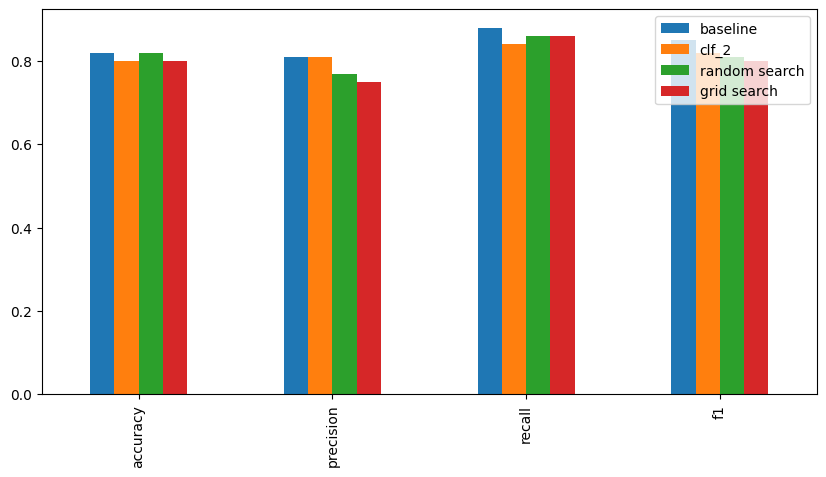

In [257]:
compare_metrics.plot(kind='bar', figsize=(10,5))

In [ ]:
topics_learnt

## Correlation analysis
There are 2 ways to do this:
* Forward Attribute(You start with one column and keep addting columns aka attributes))
* Backward Attribute(You start with all the available columns and keep removing)

The goal if we reach the plateau on the accuracy or the parameter we are looking at then we don't have to process unnecessary columns

## 6. Saving & loading trained machine learning models
1. With Python's `pickle` module, it requires large amount of RAM if the data is big
2. With `joblib` module(Use when there is a large datase or numpy) use this otherwise use pickle for smaller python objects

In [258]:
import pickle
pickle.dump(gs_clf, open("gs_random_forestmodel1.pkl", "wb"))

In [259]:
load_pickle_model = pickle.load(open("gs_random_forestmodel1.pkl", "rb"))

In [260]:
pickle_y_preds = load_pickle_model.predict(X_test)

In [261]:
evaluate_classification_preds(y_test, pickle_y_preds)

Accuracy: 80.33%
Precision : 75.00%
recall : 85.71%
f1 : 80.00


{'accuracy': 0.8, 'precision': 0.75, 'recall': 0.86, 'f1': 0.8}

In [262]:
# using joblib to save and load 
from joblib import dump, load
dump(gs_clf, filename="gs_random_forset_model_joblib.joblib")

['gs_random_forset_model_joblib.joblib']

In [263]:
load_joblib_random_forest_model  = load(filename ="gs_random_forset_model_joblib.joblib");

In [264]:
y_preds_joblib_model = load_joblib_random_forest_model.predict(X_test)

In [265]:
evaluate_classification_preds(y_test, y_preds_joblib_model)

Accuracy: 80.33%
Precision : 75.00%
recall : 85.71%
f1 : 80.00


{'accuracy': 0.8, 'precision': 0.75, 'recall': 0.86, 'f1': 0.8}

## 7.Putting it all together

Think of a Pipeline as an automated assembly line for your data.
Instead of manually doing every cleanup step one by one, you group your operations into a single, unified chain. It ensures that whatever you do to your training data happens exactly the same way to any new data.
Here is the breakdown of what is happening in your code.
#### The Breakdown of Your Code
Your snippet focuses on processing the categorical features (Make and Colour). It pipes two specific actions together:

   1. ("imputer", SimpleImputer(...)): This is the first worker on the assembly line. It looks for any missing or blank values in the Make or Colour columns and fills them with the word "missing".
   2. ("onehot", OneHotEncoder(...)): This is the second worker. Machine learning models cannot read text like "Toyota" or "Red". This worker converts those words into columns of 0s and 1s (binary vectors) so the model can understand them.

#### Why use a Pipeline?
Without a Pipeline, your code would quickly become a messy, error-prone sequence of variables:

#### The messy, manual way:imputed_data = my_imputer.fit_transform(training_data)encoded_data = my_encoder.fit_transform(imputed_data)

By using a Pipeline, you get three massive benefits:

* Cleaner Code: You bundle all your preprocessing steps into a single object.
* Prevents Data Leakage: It keeps your training logic strictly isolated from your testing data, which avoids accidentally making your model look more accurate than it actually is.
* Single Command Execution: Once your full pipeline is set up, you can clean your data and train your machine learning model simultaneously with one single line of code: pipeline.fit(X_train, y_train).

#### What Comes Next in Your Tutorial
The code you shared is just building the first piece of the puzzle. Next, the author will likely:

   1. Create pipelines for the doorFeature and numericalFeature.
   2. Merge them all together using something called a ColumnTransformer.
   3. Add a machine learning model (like a Random Forest) to the very end of the main pipeline.

If you want to stay ahead of the tutorial, let me know:

* What machine learning model (e.g., RandomForestRegressor, LinearRegression) is this tutorial using?
* Do you want to see the complete, final pipeline structure right now so you can visualize how it all connects?

You are actually 100% correct about your specific code snippet. For just filling in missing values (imputing), your ColumnTransformer approach is incredibly clean, readable, and it successfully prevents data leakage by separating fit_transform and transform.
What you are missing is what happens when you need to do multiple steps to the same column, and what happens when you deploy the model to production.
Here is exactly why Pipelines become necessary as your project grows.
#### 1. The Multi-Step Problem (Chaining Transformers)
Your ColumnTransformer only does one step per column: it imputes. But look closely at the first tutorial snippet you shared. The categorical features need two steps:

   1. Fill missing values with "missing" (SimpleImputer).
   2. Convert those words into numbers (OneHotEncoder).

Without a Pipeline inside your ColumnTransformer, your code breaks. A ColumnTransformer cannot natively pass the output of the imputer directly into the encoder.
To do it your way without a pipeline, you would have to manually create intermediate variables:

#### Without pipelines, multi-step processing gets messy fast:X_train_imputed = my_column_imputer.fit_transform(X_train)
#### Now you have to manually split columns back out to encode them...X_train_encoded = my_one_hot_encoder.fit_transform(X_train_imputed[:, [0,1]]) 

The Pipeline solution: It bundles the Imputer and Encoder together first, so the ColumnTransformer can run them back-to-back in a single clean pass.
#### 2. The Production Deployment Nightmare
Imagine you finish training your model. You save it using joblib. Now, you want to put this model onto a website where a user types in a car's details to get a price prediction.

* Your current way: You have to save, load, and manage two separate files in production: the imputer file and the model file. When a user enters data, your website code must manually pass the data through the imputer first, and then pass that result to the model. If you add a scaler later, that is a third file to manage.
* The Pipeline way: A pipeline can hold the data cleaning and the machine learning model together in one object. You save one single file.

#### The final Pipeline structurefinal_pipeline = Pipeline(steps=[
    ('preprocessor', imputer),  # Your exact ColumnTransformer
    ('model', RandomForestRegressor()) # The actual AI model
])
#### Train everything at once
final_pipeline.fit(X_train, y_train)

When you deploy final_pipeline to production, you just run:

#### Clean data and predict in one single step
final_pipeline.predict(new_user_data)

#### Summary
Your approach is excellent for a single layer of transformations. However, developers switch to Pipelines because real-world data requires chains of operations (Impute $\rightarrow$ Encode $\rightarrow$ Scale), and pipelines allow you to bind your data cleaning steps directly to your machine learning model as a single unit.
To help you see how this all connects in your tutorial, let me know:

* Does the author apply OneHotEncoding right after your imputation step?
* Would you like to see how to embed your exact ColumnTransformer inside a final production pipeline?





In [269]:
data = pd.read_csv("dataFolder/car-sales-extended-missing-data.csv")
data.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

In [271]:
data.head(2)

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0


Steps to do
1. Fill missing data
2. Convert data to number
3. Build a model on the data

In [282]:
#Getting data ready
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer # fill missing data
from sklearn.preprocessing import OneHotEncoder # convert data to numerical formats in this case "Make" etc

#Modelling
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

#Setup random seed
import numpy as np
np.random.seed(42)

# remove the missing rows in target column
print(len(data))
data = data.dropna(subset="Price")
print(len(data))

categoricalFeature = ["Make", "Colour"]
doorFeature = ["Doors"]
numericalFeature = ["Odometer (KM)"]

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean"))
])

door_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer([
    ("cat", categorical_transformer, categoricalFeature),
    ("num", numerical_transformer, numericalFeature),
    ("door", door_transformer, doorFeature)
])

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor())
]) # Preprocssing 

X=data.drop("Price", axis=1)
y = data["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model.fit(X_train, y_train)
model.score(X_test, y_test)



950
950


0.22290290923231104

In [284]:
%%time

#Using grid search with pipeline
from sklearn.model_selection import GridSearchCV
"""
     #the "preprocessor" is the name we set, "num" is the name we set likewise 
     these are all name we set and this example shows how we can use tune the imputer parameters we can tune any of the imputers
"""
pipe_grid = {
    "preprocessor__num__imputer__strategy": ["mean", "median"],
    "model__n_estimators": [100,1000], # in this case we are changing a model hyperparameters
    "model__max_depth": [None, 5],
    "model__max_features": ["sqrt"],
    "model__min_samples_split": [2,4]
}

gs_model = GridSearchCV(model, pipe_grid, cv=3, verbose=2)
gs_model.fit(X_train, y_train)


Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.2s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.1s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.1s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=median; total time=   0.1s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=median; total time=   0.1s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_s

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 5], 'model__max_features': ['sqrt'], 'model__min_samples_split': [2, 4], 'model__n_estimators': [100, 1000], ...}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`

In [285]:
gs_model.score(X_test, y_test)

0.29136617411998544